# **Titanic disaster ML modelling**

## Data Inspection and Preprocessing

In [1]:
# Import necessary libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Open the training and testing datasets, and inspect the first few rows of the training dataset
train = pd.read_csv('../dataset/train.csv'); test = pd.read_csv('../dataset/test.csv')
train.head()

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The target variable `Survived` is included on the training set. On the other hand, the testing set does not include the target variable, so we need to predict it.

In [2]:
# Let's do some basic data exploration to understand the structure of the dataset and identify any missing values or anomalies. We can check the shape of the dataset, the data types of each column, and the summary statistics for numerical columns.
print("Training dataset shape:", train.shape)
print("Testing dataset shape:", test.shape)
print("\nData types in training dataset:\n", train.dtypes)
print("\nSummary statistics for numerical columns in training dataset:\n", train.describe())

Training dataset shape: (891, 12)
Testing dataset shape: (418, 11)

Data types in training dataset:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Summary statistics for numerical columns in training dataset:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000 

In [3]:
# the target variable is included on the training dataset, but not on the testing dataset. We can check for missing values in the training dataset to see if there are any gaps in the data that we need to address before building our model.
print("\nMissing values in training dataset:\n", train.isnull().sum())


Missing values in training dataset:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Let's define the target variable and the features for our model. The target variable is typically the column we want to predict, while the features are the columns that we will use to make our predictions.
target = train['Survived']
train  = train.drop('Survived', axis=1)  # Assuming 'Survived' is the target variable

There are plenty of missing values on the `Cabin` feature, so it is better to drop it rhater than imputing the most common value (median). Further on, we can check if that variable presents high correlation with the target variable.

In [5]:
train, test = train.drop('Cabin', axis=1), test.drop('Cabin', axis=1)

For the `Age` feature, we can impute the most probable value (median), as we have 177 observations with null values and we don't want to delete the entire column as it may present an important correlation with the target variable `Survived`.

In [6]:
train.Age.fillna(train.Age.median(), inplace=True)  # Fill missing values in 'Age' with the median age
test.Age.fillna(test.Age.median(), inplace=True)    # Fill missing values in 'Age' with the median age

/tmp/ipykernel_8177/4122061206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Age.fillna(train.Age.median(), inplace=True)  # Fill missing values in 'Age' with the median age
/tmp/ipykernel_8177/4122061206.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

We proceed in a similar way for the 'Embarked' column, filling missing values with the most frequent value (mode) in that column.


In [7]:
train.Embarked.fillna(train.Embarked.mode()[0], inplace=True)  # Fill missing values in 'Embarked' with the most frequent value
test.Embarked.fillna(test.Embarked.mode()[0], inplace=True)    # Fill missing values in 'Embarked' with the most frequent value

/tmp/ipykernel_8177/3542603794.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Embarked.fillna(train.Embarked.mode()[0], inplace=True)  # Fill missing values in 'Embarked' with the most frequent value
/tmp/ipykernel_8177/3542603794.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

There's still one missing value in the `Fare` feature, specifically in the testing set. Let's impute the median.

In [8]:
test['Fare'].fillna(test['Fare'].median(), inplace=True)  # Fill missing values in 'Fare' with the median fare

/tmp/ipykernel_8177/1910750142.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Fare'].fillna(test['Fare'].median(), inplace=True)  # Fill missing values in 'Fare' with the median fare


Now that the data is clenaed, let's take a look at data types.

In [9]:
train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

Most likely, variables like `PassengerID`, `Ticket` and `Name` are not going to be useful for our model, so we can drop them from both the training and testing datasets.

In [10]:
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
train.drop(columns_to_drop, axis=1, inplace=True); test.drop(columns_to_drop, axis=1, inplace=True)

Variables `SibSp` and `Parch` refers to the number of siblings and parents of the passenger, respectively. We can create two new variables using feature engineer to improve the performance of the model. We also avoid multicollinearity as `FamilySize` is a linear combination of `SibSp` and `Parch`.

In [11]:
# Creating FamiliSize and IsAlone features
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)
train.drop(['SibSp', 'Parch'], axis=1, inplace=True)
test.drop(['SibSp', 'Parch'], axis=1, inplace=True)

Let's standarised numerical variables to be in the same range (with mean 1 and std 0)

In [12]:
# Standarised numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'Pclass', 'FamilySize']
train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
test[numerical_cols] = scaler.transform(test[numerical_cols])

Now, let's convert the categorical variables into numerical format using one-hot encoding. This will allow us to use these features further on in our machine learning model.
We can use the `pd.get_dummies()` function to achieve this. Also, we need the categorical columns to be in numerical format for correlations.

In [13]:
# Convert Sex column to numerical values using mapping
train.Sex = train.Sex.map({'male': 0, 'female': 1})
test.Sex = test.Sex.map({'male': 0, 'female': 1})

For `Embarked`, we have three possible values: S, C or Q. Let's dummify them to be sure the three categories do not have an ordinal feature.

In [14]:
# Convert Embarked column to numerical values using one-hot encoding

train = pd.concat([train, pd.get_dummies(train.Embarked, prefix='Embarked', drop_first=True, dtype=int)], axis=1)
test = pd.concat([test, pd.get_dummies(test.Embarked, prefix='Embarked', drop_first=True, dtype=int)], axis=1)
train.drop('Embarked', axis=1, inplace=True)
test.drop('Embarked', axis=1, inplace=True) 

## Data Visualization

First, let's explore the correlations between variables

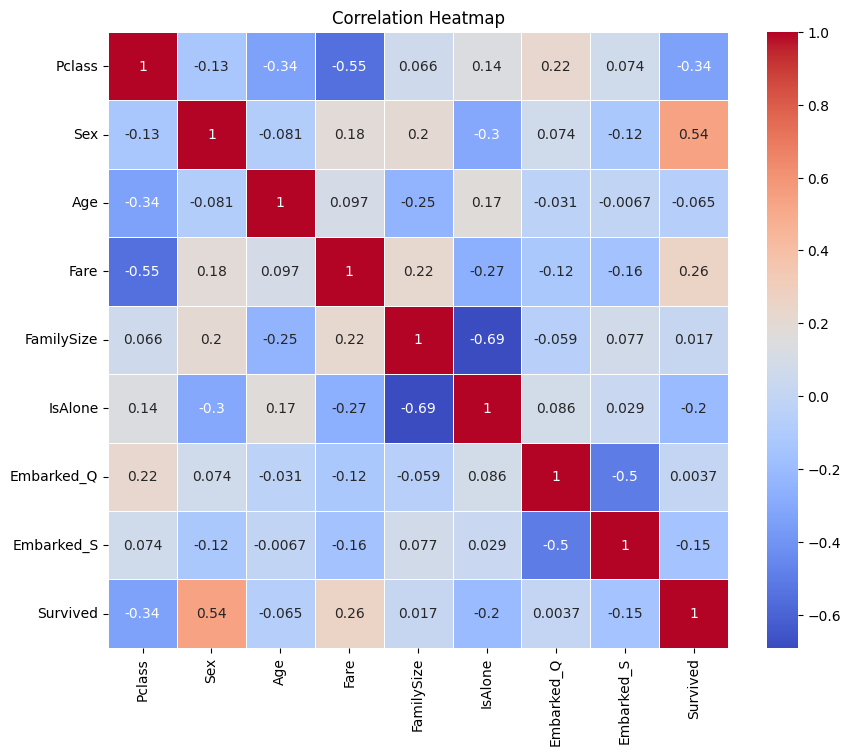

In [15]:
plt.figure(figsize=(10, 8))
df = pd.concat([train, target], axis=1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

There're some features like `Embarked_Q` or `Age` which exhibit a very small correlation with the target variable `Survived`. However, both have significant correlations with other variables that may cause underfitting if we decide to drop them. So, from now, we will preserve all variables.

Let's check the imbalance of the target variable `Survived`

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


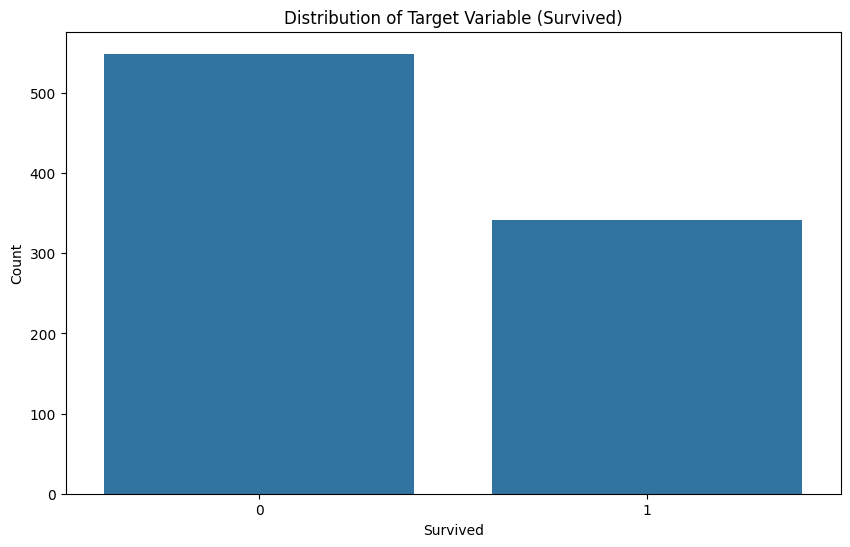

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Survived', data=pd.concat([train, target], axis=1))
plt.title('Distribution of Target Variable (Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

So the Class 0 (male) is larger than the Class 1 (female). Let's adjust our target and training set to have the same number of male and female passengers using `sklearn.resample`

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


<Axes: xlabel='Survived', ylabel='count'>

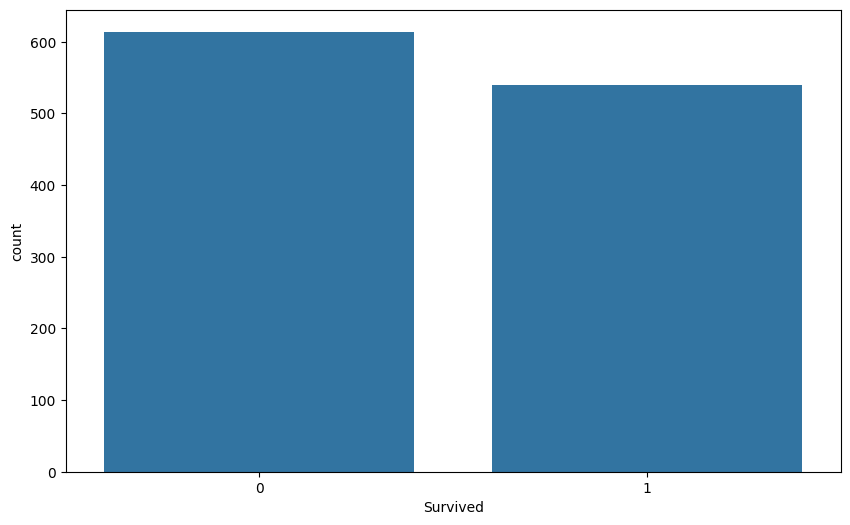

In [17]:
# We need to cut the training variables with respect to the Sex variable, in order to get the same number of 0s and 1s in the target variable. 
# This is important because if we have an imbalanced dataset, our model may be biased towards the majority class and perform poorly on the minority class.
train.Sex.value_counts()

from sklearn.utils import resample # Using resample to balance the dataset by oversampling the minority class
X_class0 = train[train.Sex == 0]  # Class 0
X_class1 = train[train.Sex == 1]  # Class 1
y_class0 = target[train.Sex == 0]  # Target variable for class 0
y_class1 = target[train.Sex == 1]  # Target variable for class 1

X_class1_upsampled, y_class1_upsampled = resample(X_class1, y_class1, replace=True, n_samples=len(X_class0), random_state=42)
X_balanced = pd.concat([X_class0, X_class1_upsampled])  # Combine the original class 0 with the upsampled class 1
y_balanced = pd.concat([y_class0, y_class1_upsampled])

plt.figure(figsize=(10, 6))
sns.countplot(x=y_balanced)

So now we have a balanced dataset with an equal number of samples for both classes, which should help our model perform better on the minority class.

## ML models for predicting if a passenger survived

We are ready to test some ML models and check their performance on predicting over the testing set. We will try with Logistic Regression, Random Forest and XGBoost, and if so, we will check a Neural Network to improve the performance. Nonetheless, as we are planning to use grid search cross-validation to improve the accuracy of our model, we split the training set into training and validation. We also use `gender_submission.csv` file to check the accuracy of our model.

In [18]:
# Splitting the training data into training and validation sets to evaluate the performance of our model before testing it on the unseen test dataset.
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Importing gender_submission file to get the PassengerId for the test dataset, which we will need when we make our predictions and submit them to the competition.
y_test = pd.read_csv('../dataset/gender_submission.csv')
y_test = y_test['Survived'].values

### Logistic Regression

In [20]:
# Let's import the necessary libraries for building and evaluating our machine learning model. We will use a simple logistic regression model for this task.
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(random_state=42)
LR.fit(X_train, y_train)

# First, we will make predictions on the training dataset to evaluate the performance of our model. We can use metrics such as accuracy, precision, recall, and F1-score to assess how well our model is performing.
from sklearn.metrics import classification_report, confusion_matrix
y_pred_train = LR.predict(X_train)
print("Classification Report for Training Data:\n", classification_report(y_train, y_pred_train))

Classification Report for Training Data:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82       493
           1       0.78      0.84      0.81       430

    accuracy                           0.81       923
   macro avg       0.81      0.82      0.81       923
weighted avg       0.82      0.81      0.81       923



In [21]:
# Use grid search to find the best hyperparameters for our logistic regression model. This will help us improve the performance of our model by tuning the regularization strength and other parameters.
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}
grid_search = GridSearchCV(estimator=LR, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train) # We fit the grid search on the training set (GridSearchCV does internal cross-validation)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'C': 1, 'penalty': 'l2'}


/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/linear_mod

In [22]:
# Check the accuracy of the best parameters on test set
best_LR = grid_search.best_estimator_
y_pred_val = best_LR.predict(X_val)
print("Classification Report for Validation Data:\n", classification_report(y_val, y_pred_val))

Classification Report for Validation Data:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78       121
           1       0.75      0.78      0.77       110

    accuracy                           0.77       231
   macro avg       0.77      0.78      0.77       231
weighted avg       0.78      0.77      0.78       231



In [23]:
# Predicting the target variable for the testing dataset using the trained logistic regression model. We will then create a submission file in the required format for the Kaggle competition.
y_pred_test = best_LR.predict(test)
submission = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': y_pred_test})
submission.to_csv('../submissions/submission_LR.csv', index=False)

### Random Forest Classifier

In [57]:
# Let's try with a random forest classifier to see if we can improve our model's performance. Random forests are an ensemble learning method that can capture complex relationships in the data and often perform well on classification tasks.
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)
y_pred_train_rf = RF.predict(X_train)
print("Classification Report for Training Data (Random Forest):\n", classification_report(y_train, y_pred_train_rf))

Classification Report for Training Data (Random Forest):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       493
           1       0.99      0.98      0.99       430

    accuracy                           0.99       923
   macro avg       0.99      0.99      0.99       923
weighted avg       0.99      0.99      0.99       923



The model is overfitting. We can delete minor features from the model that may lead to overfitting

In [60]:
# Applying grid search to find the best hyperparameters for our random forest model. This will help us improve the performance of our model by tuning parameters such as the number of trees in the forest and the maximum depth of the trees.
param_grid_rf = {'n_estimators': [100], 'max_depth': [10],
                 'min_samples_split': [5], 'min_samples_leaf': [2],
                 'max_features': ['log2']}
grid_search_rf = GridSearchCV(estimator=RF, param_grid=param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)

Best Hyperparameters for Random Forest: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [61]:
# Check the accuracy of the best parameters on test set
best_rf = grid_search_rf.best_estimator_
y_pred_val = best_rf.predict(X_val)
print("Classification Report for Test Data:\n", classification_report(y_val, y_pred_val))

Classification Report for Test Data:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       121
           1       0.88      0.75      0.81       110

    accuracy                           0.84       231
   macro avg       0.84      0.83      0.83       231
weighted avg       0.84      0.84      0.83       231



In [37]:
# Predicting and submitting results for the random forest model
y_pred_test_rf = best_rf.predict(test)
submission_rf = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': y_pred_test_rf})
submission_rf.to_csv('../submissions/submission_RF.csv', index=False)

### XGBoost

In [38]:
# Import the XGBoost classifier and train the model
from xgboost import XGBClassifier
XGB = XGBClassifier(random_state=42)
XGB.fit(X_train, y_train)
y_pred_train_xgb = XGB.predict(X_train)
print("Classification Report for Training Data (XGBoost):\n", classification_report(y_train, y_pred_train_xgb))

Classification Report for Training Data (XGBoost):
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       493
           1       0.99      0.96      0.98       430

    accuracy                           0.98       923
   macro avg       0.98      0.98      0.98       923
weighted avg       0.98      0.98      0.98       923



In [39]:
# Using grid search to find the best hyperparameters for our XGBoost model. This will help us improve the performance of our model by tuning parameters such as the learning rate and the number of estimators.
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2],
                  'max_depth': [3, 5, 7], 'reg_alpha': [0, 0.1, 1], 'reg_lambda': [1, 2, 5],
                  'min_child_weight': [3, 5, 7]}
grid_search_xgb = GridSearchCV(estimator=XGB, param_grid=param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train, y_train)
print("Best Hyperparameters for XGBoost:", grid_search_xgb.best_params_)

Best Hyperparameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1}


In [40]:
# Check the accuracy of the best parameters on test set
best_xgb = grid_search_xgb.best_estimator_
y_pred_val = best_xgb.predict(X_val)
print("Classification Report for Test Data:\n", classification_report(y_val, y_pred_val))

Classification Report for Test Data:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       121
           1       0.89      0.79      0.84       110

    accuracy                           0.85       231
   macro avg       0.86      0.85      0.85       231
weighted avg       0.86      0.85      0.85       231



In [41]:
# Predictions on the test dataset using the XGBoost model and creating a submission file
y_pred_test_xgb = best_xgb.predict(test)
submission_xgb = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': y_pred_test_xgb})
submission_xgb.to_csv('../submissions/submission_XGB.csv', index=False)

### Dense Neural Network

As a final exercise, we can build a deep neural network with multiple hidden layers using PyTorch. We will also incorporate Dropout layers for overfitting prevention along with momentum to prevent gradient descent to not be able to reach the global minimum when computing the loss function.

In [80]:
# Using PyTorch Custom Module to create a neural network for classification. This will allow us to build a more complex model that can capture non-linear relationships in the data and potentially improve our predictions.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Creating the neural network architecture by defining a custom module that inherits from nn.Module. We will also incorporate Dropout layers to prevent overfitting and ReLU activation functions to introduce non-linearity into the model.
class TitanicNN(nn.Module):
    def __init__(self, H_1, H_2, input_size):
        super(TitanicNN, self).__init__()
        self.fc1 = nn.Linear(input_size, H_1)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(H_1, H_2)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(H_2, 1)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x
    
# Preparing the training, validation and testing sets as torch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32)
X_test_tensor  = torch.tensor(test.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32)

We now can start training the DNN by calling the optimizer and the loss function, and training the model for 50 epochs

In [81]:
input_dim = X_train_tensor.shape[1] # Input dimension is the number of features in the training dataset
model = TitanicNN(128, 64, input_dim) # Instantiate the model with the input dimension
criterion = nn.BCEWithLogitsLoss() # Binary Cross-Entropy Loss for binary classification
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam optimizer with a learning rate of 0.001

epochs = 500

# Training tensor datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Validation tensor datasets
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Testing tensor datasets
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Dictionary to store the training and validation losses and accuracies for each epoch, which we can use to plot the learning curves and analyze the model's performance over time.
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# Training the model for a specified number of epochs, where we will iterate through the training data in batches, compute the loss, and update the model parameters using backpropagation and the optimizer.
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    train_loss = 0
    train_correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()  # Clear the gradients
        output = model(data)  # Forward pass
        loss = criterion(output, target.view(-1, 1))  # Compute the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update the model parameters
        
        train_loss += loss.item()  # Accumulate the training loss
        pred = (torch.sigmoid(output) > 0.5).float()  # Apply sigmoid for prediction
        train_correct += (pred == target.view(-1, 1)).sum().item()  # Count correct predictions
        
    # Calculate training metrics
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = train_correct / len(train_loader.dataset)
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_accuracy)

    # After each epoch, we will evaluate the model on the validation set to monitor its performance and check for overfitting. We can compute metrics such as accuracy, precision, recall, and F1-score to assess how well our model is performing on the validation data.
    model.eval()  # Set the model to evaluation mode
    val_loss = 0
    val_correct = 0
    with torch.no_grad():  # Disable gradient calculation for validation
        for data, target in val_loader:
            output = model(data)  # Forward pass
            val_loss += criterion(output, target.view(-1, 1)).item()  # Compute the loss
            pred = (torch.sigmoid(output) > 0.5).float()  # Apply sigmoid for prediction
            val_correct += (pred == target.view(-1, 1)).sum().item()  # Count correct predictions
            
    avg_val_loss = val_loss / len(val_loader)  # Average validation loss
    val_accuracy = val_correct / len(val_loader.dataset)  # Validation accuracy
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)
    if (epoch + 1) % 100 == 0:  # Print the validation loss and accuracy every 10 epochs
        print(f'Epoch: {epoch+1}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

# After training the model, we will make predictions on the test dataset and create a submission file in the required format for the Kaggle competition.
model.eval()  # Set the model to evaluation mode
test_predictions = []
with torch.no_grad():  # Disable gradient calculation for testing
    for data, _ in test_loader:
        output = model(data)  # Forward pass
        pred = (output > 0.5).float()  # Convert probabilities to binary predictions
        test_predictions.extend(pred.cpu().numpy())  # Collect predictions into a list
submission_nn = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': np.array(test_predictions).flatten().astype(int)})
submission_nn.to_csv('../submissions/submission_NN.csv', index=False)

Epoch: 100, Validation Loss: 0.5331, Validation Accuracy: 0.8182
Epoch: 200, Validation Loss: 0.5738, Validation Accuracy: 0.8312
Epoch: 300, Validation Loss: 0.6519, Validation Accuracy: 0.8139
Epoch: 400, Validation Loss: 0.7348, Validation Accuracy: 0.8312
Epoch: 500, Validation Loss: 0.8472, Validation Accuracy: 0.8182


Visualising both the training and validation losses and accuracies for each epoch

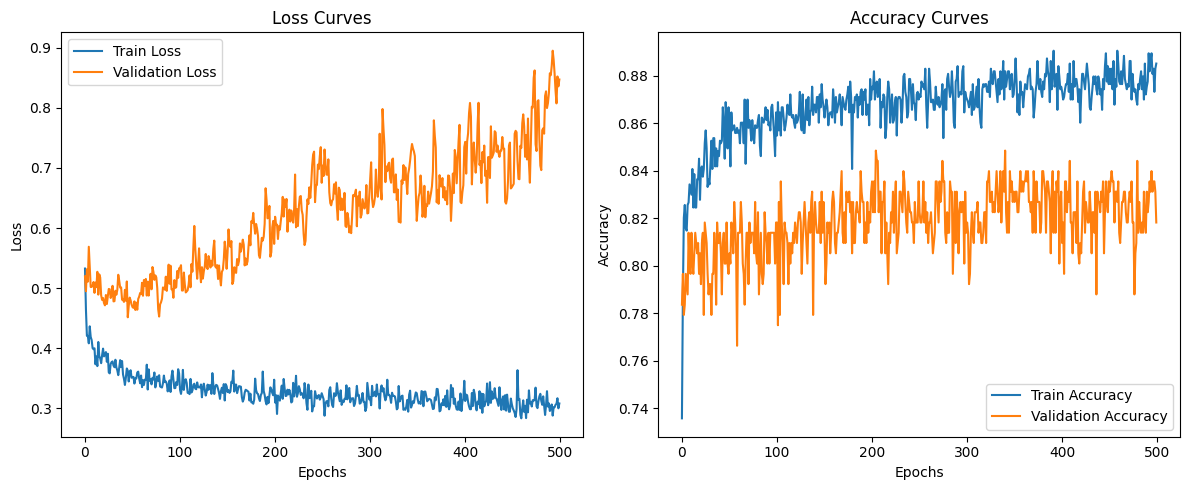

In [82]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Confusion matrices
Confusion matrix of training test: [[469  24]
 [ 84 346]]
Confusion matrix of validation test: [[111  10]
 [ 33  77]]


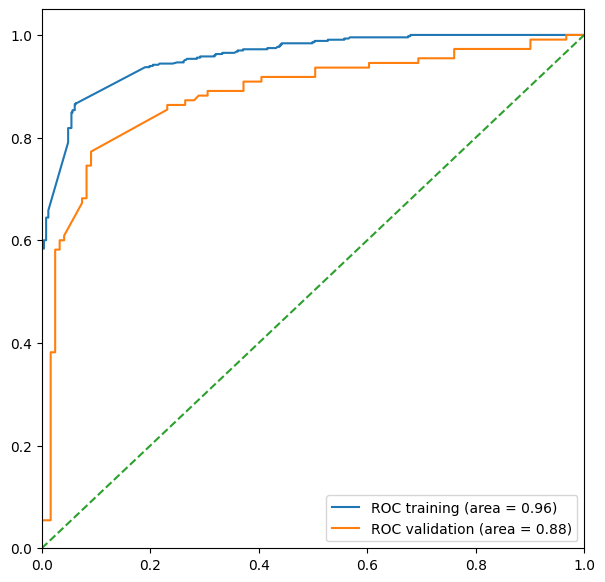


Classification reports
Training:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       493
           1       0.94      0.80      0.86       430

    accuracy                           0.88       923
   macro avg       0.89      0.88      0.88       923
weighted avg       0.89      0.88      0.88       923


Validation
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       121
           1       0.89      0.70      0.78       110

    accuracy                           0.81       231
   macro avg       0.83      0.81      0.81       231
weighted avg       0.83      0.81      0.81       231



In [83]:
## Write your code here
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Writting a function to visualise metrics for the model with or without regularisation
def visual_metrics(model):

    # Model without regularisation
    model.eval()
    with torch.no_grad():
        train_outputs = model(X_train_tensor)
        val_outputs = model(X_val_tensor)

    # Making predictions assuming a probability of 0.5
    y_pred_train = (train_outputs > 0.5).float()
    y_pred_val  = (val_outputs > 0.5).float()

    # Now, we need to convert into a numpy integer in order to compute cofussion matrix. We also need to flatten the vectors
    # as to be of dimension (n,) instead of (n,1)
    y_pred_train = y_pred_train.detach().numpy().astype(int).flatten()
    y_pred_val = y_pred_val.detach().numpy().astype(int).flatten()

    # Confussion matrices
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_val = confusion_matrix(y_val, y_pred_val)

    print('Confusion matrices')
    print(f'Confusion matrix of training test: {cm_train}')
    print(f'Confusion matrix of validation test: {cm_val}')

    # ROC-AUC curve
    fpr_train, tpr_train, tresholds_train = roc_curve(y_train, train_outputs.detach().numpy())
    roc_auc_train = auc(fpr_train, tpr_train)
    fpr_val, tpr_val, tresholds_val = roc_curve(y_val, val_outputs.detach().numpy())
    roc_auc_val = auc(fpr_val, tpr_val)

    plt.figure(figsize=(7,7))
    plt.plot(fpr_train, tpr_train, label=f'ROC training (area = {roc_auc_train:.2f})')
    plt.plot(fpr_val, tpr_val, label=f'ROC validation (area = {roc_auc_val:.2f})')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.05)
    plt.legend()
    plt.show()

    # Classification report
    print('\nClassification reports')
    print('Training:')
    print(classification_report(y_train, y_pred_train))
    print('\nValidation')
    print(classification_report(y_val, y_pred_val))

visual_metrics(model)

## Model comparison

Let's compare the three models after grid search cross-validation to evaluate the performance on the testing

In [ ]:
# Comparing the accuracy of the three models (Logistic Regression, Random Forest, and XGBoost) on the testing set to determine which model performs best.
best_LR.predict(test); best_rf.predict(test); best_xgb.predict(test)

from sklearn.metrics import accuracy_score
accuracy_lr = accuracy_score(y_test, best_LR.predict(test))
accuracy_rf = accuracy_score(y_test, best_rf.predict(test))
accuracy_xgb = accuracy_score(y_test, best_xgb.predict(test))

print(f"Accuracy of Logistic Regression: {accuracy_lr:.4f}")
print(f"Accuracy of Random Forest: {accuracy_rf:.4f}")
print(f"Accuracy of XGBoost: {accuracy_xgb:.4f}")

Accuracy of Logistic Regression: 0.9163
Accuracy of Random Forest: 0.8876
Accuracy of XGBoost: 0.8469


So Logistic Regression is the model that best captures the features of the dataset and the one that offers the best performance.